In [1]:
import pandas as pd
import numpy as np
import os


from matplotlib import pyplot as plt
import sklearn.ensemble

from sklearn import preprocessing
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
import graphviz

from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

from sklearn.decomposition import PCA

from sklearn.model_selection import cross_val_score
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve, auc

from anchor import utils
from anchor import anchor_tabular

from xailib.data_loaders.dataframe_loader import prepare_dataframe

from xailib.explainers.lime_explainer import LimeXAITabularExplainer
from xailib.explainers.lore_explainer import LoreTabularExplainer
from xailib.explainers.shap_explainer_tab import ShapXAITabularExplainer

from xailib.models.sklearn_classifier_wrapper import sklearn_classifier_wrapper

from plot_explanation import PlotExplanation


In [2]:
path = os.getcwd()
print(path)
source_file=f'../../datasets/mushrooms.csv'

/Users/eleonoracappuccio/xai-visualization_rules_fi/notebooks/experiments_dataset+anchor


In [3]:
class_field = 'class'
df=pd.read_csv(source_file)
df.head(10)

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
5,e,x,y,y,t,a,f,c,b,n,...,s,w,w,p,w,o,p,k,n,g
6,e,b,s,w,t,a,f,c,b,g,...,s,w,w,p,w,o,p,k,n,m
7,e,b,y,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,s,m
8,p,x,y,w,t,p,f,c,n,p,...,s,w,w,p,w,o,p,k,v,g
9,e,b,s,y,t,a,f,c,b,g,...,s,w,w,p,w,o,p,k,s,m


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [5]:
df.isnull().sum()

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

In [6]:
y_label = df['class'].unique()

In [7]:
y_label

array(['p', 'e'], dtype=object)

In [8]:
df.shape

(8124, 23)

In [9]:
df, feature_names, class_values, numeric_columns, rdf, real_feature_names, features_map = prepare_dataframe(df, class_field)

### Data description

In [10]:
df.describe()

,cap-shape=b,cap-shape=c,cap-shape=f,cap-shape=k,cap-shape=s,cap-shape=x,cap-surface=f,cap-surface=g,cap-surface=s,cap-surface=y,...,population=v,population=y,habitat=d,habitat=g,habitat=l,habitat=m,habitat=p,habitat=u,habitat=w,class
count,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,...,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000
mean,0.055638,0.000492,0.387986,0.101920,0.003939,0.450025,0.285574,0.000492,0.314623,0.399311,...,0.497292,0.210734,0.387494,0.264402,0.102413,0.035943,0.140817,0.045298,0.023634,0.482029
std,0.229235,0.022185,0.487321,0.302562,0.062641,0.497527,0.451715,0.022185,0.464394,0.489787,...,0.500023,0.407855,0.487208,0.441041,0.303209,0.186159,0.347854,0.207969,0.151914,0.499708
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Cardinality

In [11]:
count_df = pd.DataFrame()
for col in df.columns:
    column_counts = df[col].value_counts().reset_index()
    column_counts.columns = ['Category', f'Count_{col}']
    count_df = pd.concat([count_df, column_counts], axis=1)
count_df.head(20)

,Category,Count_cap-shape=b,Category,Count_cap-shape=c,Category,Count_cap-shape=f,Category,Count_cap-shape=k,Category,Count_cap-shape=s,...,Category,Count_habitat=m,Category,Count_habitat=p,Category,Count_habitat=u,Category,Count_habitat=w,Category,Count_class
0,0,7672,0,8120,0,4972,0,7296,0,8092,...,0,7832,0,6980,0,7756,0,7932,0,4208
1,1,452,1,4,1,3152,1,828,1,32,...,1,292,1,1144,1,368,1,192,1,3916


## The dataset has values in strings. We need to convert all the unique values to integers. Perform label encoding on the data.

In [12]:
labelencoder=LabelEncoder()
for col in df.columns:
    df[col] = labelencoder.fit_transform(df[col])
 
df.head()

,cap-shape=b,cap-shape=c,cap-shape=f,cap-shape=k,cap-shape=s,cap-shape=x,cap-surface=f,cap-surface=g,cap-surface=s,cap-surface=y,...,population=v,population=y,habitat=d,habitat=g,habitat=l,habitat=m,habitat=p,habitat=u,habitat=w,class
0,0,0,0,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,1,0,1
1,0,0,0,0,0,1,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
3,0,0,0,0,0,1,0,0,0,1,...,0,0,0,0,0,0,0,1,0,1
4,0,0,0,0,0,1,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0


In [13]:
df['class'].unique()

array([1, 0])

In [14]:
print(df.groupby('class').size())

class
0    4208
1    3916
dtype: int64


In [15]:
df.corr()

,cap-shape=b,cap-shape=c,cap-shape=f,cap-shape=k,cap-shape=s,cap-shape=x,cap-surface=f,cap-surface=g,cap-surface=s,cap-surface=y,...,population=v,population=y,habitat=d,habitat=g,habitat=l,habitat=m,habitat=p,habitat=u,habitat=w,class
cap-shape=b,1.000000,-0.005387,-0.193260,-0.081769,-0.015264,-0.219564,-0.091638,0.018820,0.117712,-0.027947,...,-0.168381,-0.120154,-0.182037,0.149151,0.010113,0.374316,-0.095178,-0.052871,-0.037764,-0.182567
cap-shape=c,-0.005387,1.000000,-0.017672,-0.007477,-0.001396,-0.020077,-0.014032,0.249631,-0.015038,0.015893,...,-0.022075,-0.011469,-0.017653,-0.013306,0.065707,-0.004286,-0.008985,-0.004835,-0.003453,0.023007
cap-shape=f,-0.193260,-0.017672,1.000000,-0.268226,-0.050070,-0.720235,0.064801,-0.006285,-0.093397,0.029076,...,0.034625,0.111346,0.074986,-0.017982,-0.052326,-0.129312,0.021891,0.030636,-0.017450,0.018526
cap-shape=k,-0.081769,-0.007477,-0.268226,1.000000,-0.021185,-0.304733,-0.158942,0.010863,0.137988,0.015261,...,0.172707,-0.170081,-0.089230,-0.113404,0.235108,-0.065047,0.090538,-0.073380,0.119003,0.163565
cap-shape=s,-0.015264,-0.001396,-0.050070,-0.021185,1.000000,-0.056884,0.099464,-0.001396,-0.042607,-0.051272,...,0.000341,0.044603,-0.050018,-0.037702,-0.021242,-0.012142,-0.025458,0.288697,-0.009784,-0.060664
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
habitat=m,0.374316,-0.004286,-0.129312,-0.065047,-0.012142,-0.004529,-0.122077,-0.004286,0.077081,0.039697,...,-0.144434,-0.099772,-0.153579,-0.115762,-0.065222,1.000000,-0.078170,-0.042059,-0.030041,-0.138627
habitat=p,-0.095178,-0.008985,0.021891,0.090538,-0.025458,-0.029042,-0.086727,-0.008985,-0.039574,0.117915,...,0.169228,0.040714,-0.322005,-0.242715,-0.136749,-0.078170,1.000000,-0.088184,-0.062986,0.323346
habitat=u,-0.052871,-0.004835,0.030636,-0.073380,0.288697,0.002845,-0.011913,-0.004835,0.117548,-0.100248,...,0.001180,-0.042888,-0.173254,-0.130592,-0.073577,-0.042059,-0.088184,1.000000,-0.033889,0.112078
habitat=w,-0.037764,-0.003453,-0.017450,0.119003,-0.009784,-0.036493,-0.098365,-0.003453,0.062109,0.031986,...,-0.154742,-0.080392,-0.123748,-0.093276,-0.052553,-0.030041,-0.062986,-0.033889,1.000000,-0.150087


### Standardising the data

In [ ]:
scaler = MinMaxScaler()

In [ ]:
col_name = df.columns.values
col_name = list(col_name)

In [ ]:
print(col_name)

In [ ]:
df_scaled = scaler.fit_transform(df.to_numpy())
df_scaled = pd.DataFrame(df_scaled, columns=col_name)
 
print("Scaled Dataset Using MinMaxScaler")
df_scaled.head()

### Non super utile

In [ ]:
X = df.iloc[:,1:23]  # all rows, all the features and no labels
y = df.iloc[:, 0]  # all rows, label only
X.head()
y.head()

In [ ]:
scaler = StandardScaler()
X=scaler.fit_transform(X)
X

### PCA

In [ ]:
pca = PCA()
pca.fit_transform(X)

In [ ]:
covariance=pca.get_covariance()

In [ ]:
explained_variance=pca.explained_variance_
explained_variance

In [ ]:
with plt.style.context('dark_background'):
    plt.figure(figsize=(6, 4))
    
    plt.bar(range(22), explained_variance, alpha=0.5, align='center',
            label='individual explained variance')
    plt.ylabel('Explained variance ratio')
    plt.xlabel('Principal components')
    plt.legend(loc='best')
    plt.tight_layout()

### Split into train and test

In [16]:
X = df.drop('class', axis=1)  # Features (all columns except 'target_class')
y = df['class']

In [17]:
y.head()

0    1
1    0
2    0
3    1
4    0
Name: class, dtype: int64

In [18]:
test_size = 0.8
random_state = 4
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                        test_size=test_size,
                                                        random_state=random_state
                                                    )

## SINGLE DECISION TREE

In [19]:
dt_gini = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=0)


# fit the model
dt_gini.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=0)

In [20]:
y_pred_gini = dt_gini.predict(X_test)

In [21]:
y_prob = dt_gini.predict_proba(X_test)[:,1] # This will give you positive class prediction probabilities  
y_pred = np.where(y_prob > 0.5, 1, 0) # This will threshold the probabilities to give class predictions.
dt_gini.score(X_test, y_pred)

1.0

In [22]:
confusion_matrix=metrics.confusion_matrix(y_test,y_pred)
confusion_matrix

array([[3260,   91],
       [   5, 3144]])

In [23]:
# print the scores on training and test set

print('Training set score: {:.4f}'.format(dt_gini.score(X_train, y_train)))

print('Test set score: {:.4f}'.format(dt_gini.score(X_test, y_test)))

Training set score: 0.9852
Test set score: 0.9852


In [24]:
df['class']

0       1
1       0
2       0
3       1
4       0
       ..
8119    0
8120    0
8121    0
8122    1
8123    0
Name: class, Length: 8124, dtype: int64

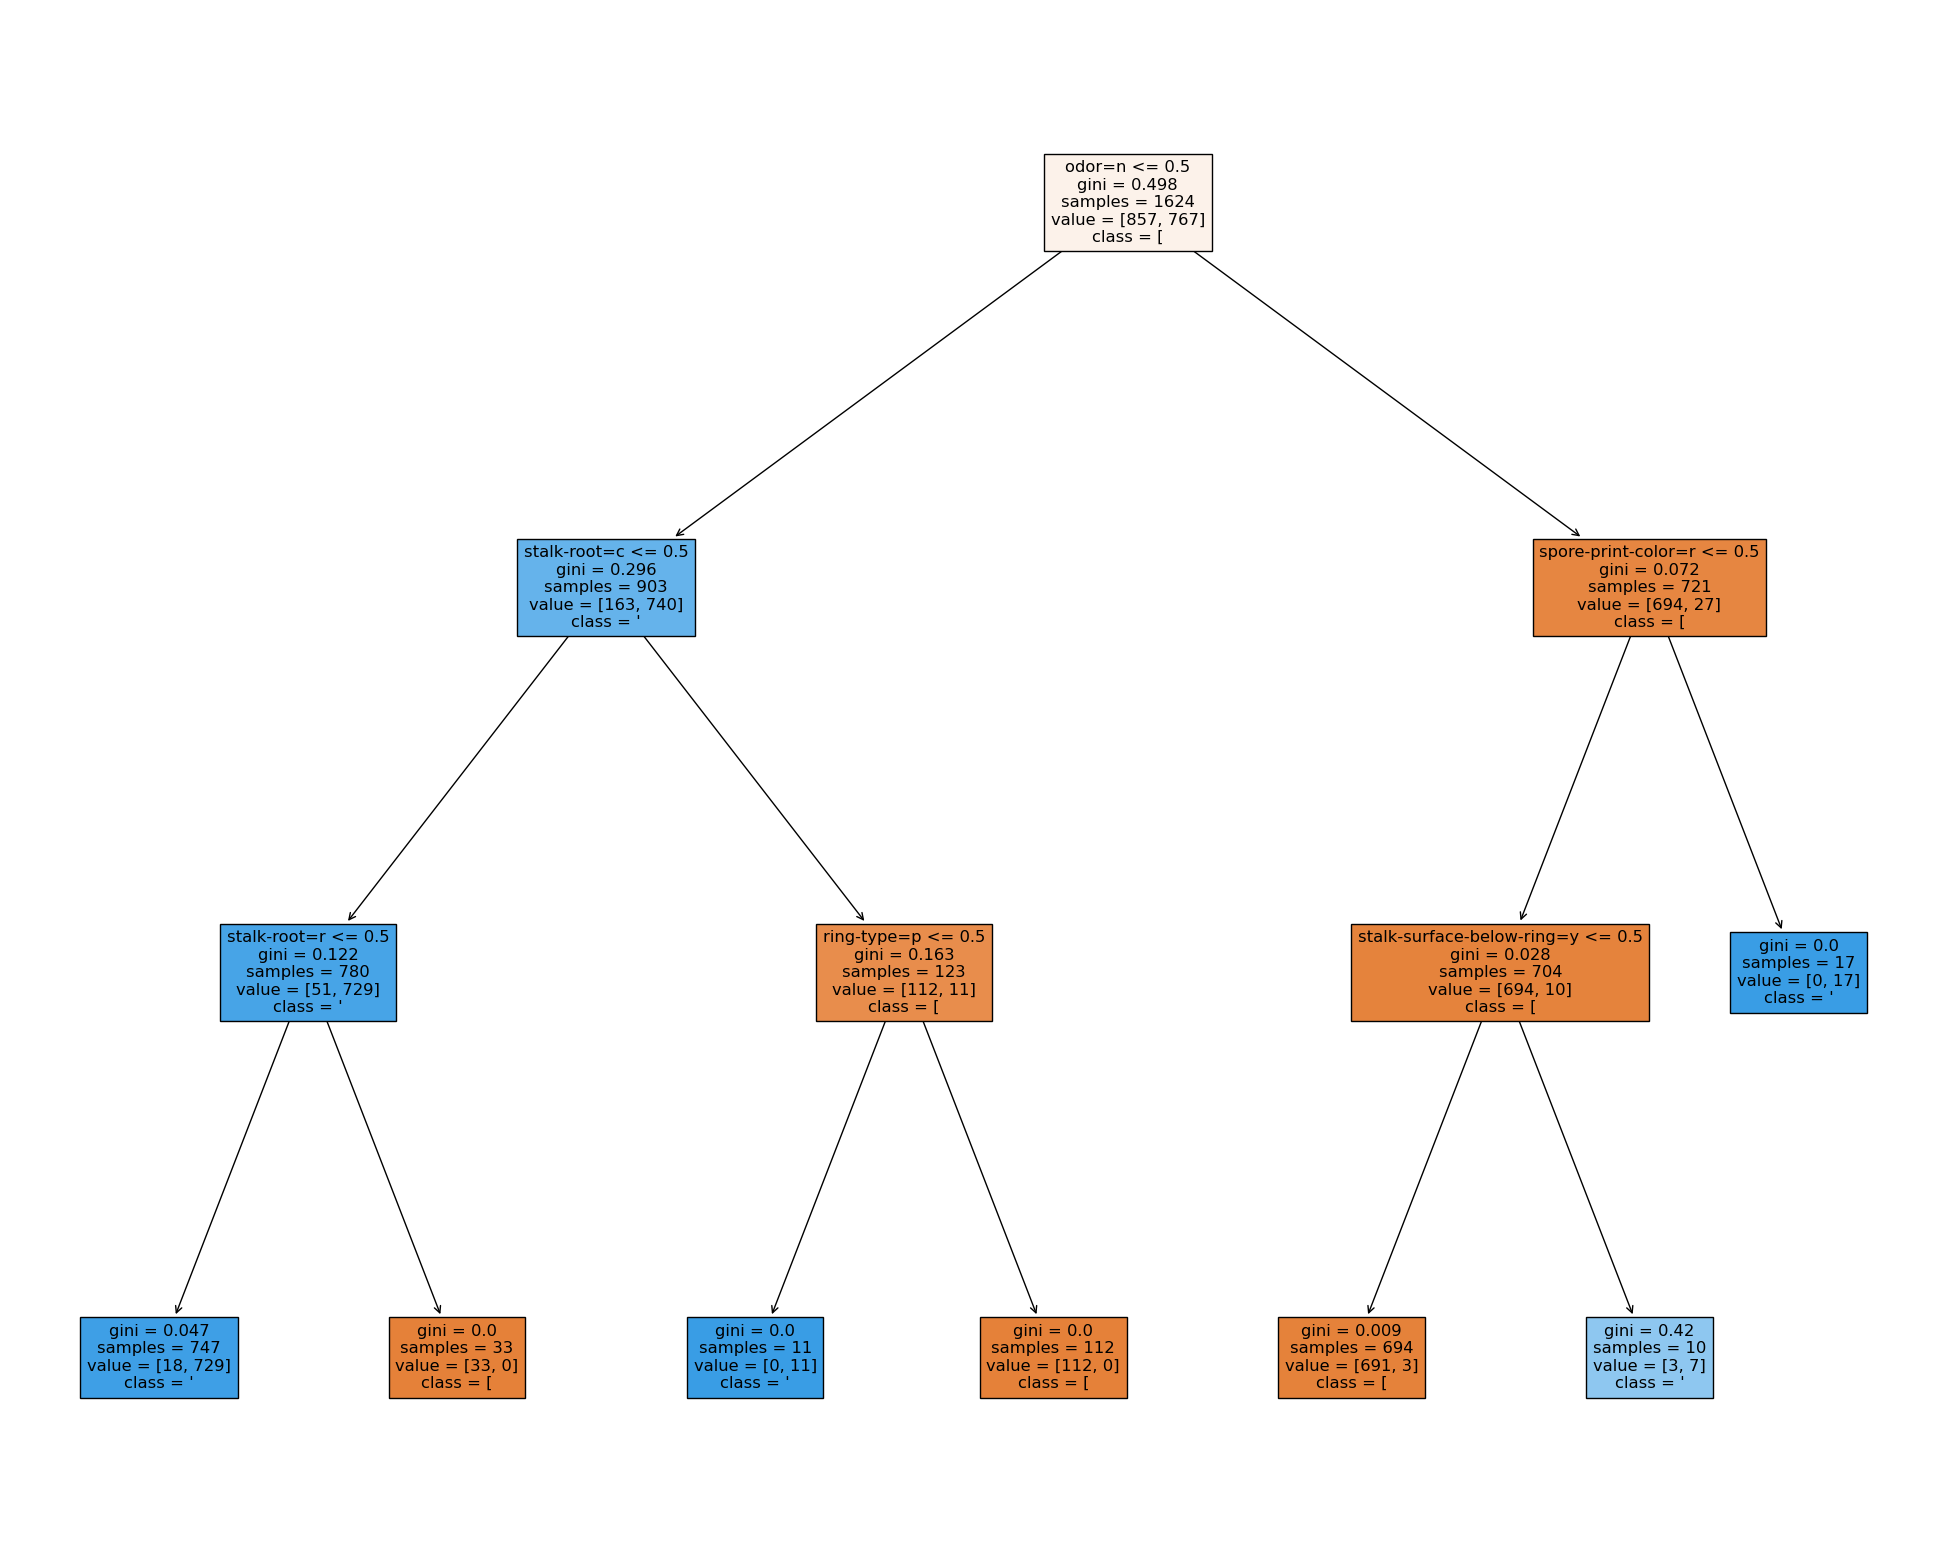

In [25]:
fig = plt.figure(figsize=(25,20))
_ = tree.plot_tree(dt_gini, 
                   feature_names=X.columns.values,  
                   class_names=str(y_label),
                   filled=True)

### LORE

Select a new instance to be classfied by the model and print the predicted class.

In [28]:
dt_gini_box = sklearn_classifier_wrapper(dt_gini)

In [29]:
r=list(range(0,6))
for i in r:
    inst = X_train.iloc[i].values
    print('Instance ',inst)
    print('True class ',y_train.iloc[6])
    print('Predicted class ',dt_gini.predict(inst.reshape(1, -1)))
    explainer = LoreTabularExplainer(dt_gini_box)
    config = {'neigh_type':'geneticp', 'size':1000, 'ocr':0.1, 'ngen':10}
    explainer.fit(df, class_field, config)

    exp = explainer.explain(inst)
    print(exp)
    exp.expDict

Instance  [0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 1 1 0 1 0
 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0
 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1
 0 0 0 0 0 0]
True class  0
Predicted class  [0]
Instance  [0 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 1 0 1 0 1 0
 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 1
 0 0 0 0 0 0]
True class  0
Predicted class  [1]
Instance  [0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 1 0 1 0
 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 1
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0
 0 0 0 1 0 0]
True class  0
Predicted class  [1]
Instance  [0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 1 0 0 0 0 0 0 0 1 1 0 1 0
 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 

In [30]:
exp.plotRules()

In [50]:
lore_exp=exp.expDict

In [31]:
exp.plotCounterfactualRules()

### SHAP

In [33]:
explainer = ShapXAITabularExplainer(dt_gini_box, feature_names)
config = {'explainer' : 'tree', 'X_train' : X_train[0:300]}
explainer.fit(config)

In [34]:
exp_s = explainer.explain(inst)
print(exp)

In [35]:
result = exp_s.getFeaturesImportance()

In [36]:
result

[array([ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.48586587,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        , -0.03365677,  0.        ,
        -0.01043646,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.00706116,  0.        ,
         0.        ,  0.        ,  0.        ,  0. 

In [55]:
numeric_columns

[]

In [61]:
pe = PlotExplanation(feature_names=feature_names,
            real_feature_names=real_feature_names,
            numeric_columns=numeric_columns,
            instance_number=1,
            x_train=X_train,
            expDict= lore_exp,
            feature_importance_type='shap',
            feature_importance=result)

In [62]:
df_v = pe.prepare_dataframe() ### cerca di iterare su numeric columns anche se è vuota

KeyError: 'max'

In [ ]:
import json

with open(f'instance_{inst_num}.json', "w") as outfile:
    json.dump(rule_descr, outfile, cls=ExplanationEncoder, indent=4)

### ANCHOR
https://github.com/marcotcr/anchor/blob/master/notebooks/Anchor%20on%20tabular%20data.ipynb


Per ANCHOR bisogna formattare il dataset in modo che ci sia:
- class_names: una lista coi valori della classe da predirre
- feature_names: lista dei nomi delle colonne
- train: array dei dati di training
- test: array dei dati di test
- labels_test: array con del y_test
- categorical_names: un dizionario che ha come key il numero della colonna categorica e come value la lista delle categorie

In [ ]:
class_field = 'class'
df_a=pd.read_csv(source_file)
df_a.head(10)

In [ ]:
X = df_a.drop('class', axis=1)  # Features (all columns except 'class')
y = df_a['class']  # Target class

In [ ]:
class_names = list(df_a['class'].unique())
feature_names = list(X.columns)
    # Initialize an empty dictionary to store the results
categorical_names = {}
    # Loop through the columns of the DataFrame
for col_num, col_name in enumerate(X.columns):
    if X[col_name].dtype == 'object':  # Check if the column is categorical
        unique_categories = X[col_name].unique().tolist()
        categorical_names[col_num] = unique_categories
    categorical_names

In [ ]:
labelencoder=LabelEncoder()
for col in X.columns:
    X[col] = labelencoder.fit_transform(X[col])
X.head()
y = labelencoder.fit_transform(y)


In [ ]:
categorical_names

In [ ]:
test_size = 0.4
random_state = 4
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                        test_size=test_size,
                                                        random_state=random_state,
                                                        stratify=y)

In [ ]:
c = sklearn.ensemble.RandomForestClassifier(n_estimators=50, n_jobs=5)
c.fit(X_train.values, y_train)
print('Train', sklearn.metrics.accuracy_score(y_train, c.predict(X_train.values)))
print('Test', sklearn.metrics.accuracy_score(y_test, c.predict(X_test.values)))

In [ ]:
explainer = anchor_tabular.AnchorTabularExplainer(
    class_names,
    feature_names,
    X_train.values,
    categorical_names)

In [ ]:
feature_names

In [ ]:
explainer.class_names

In [ ]:
idx = 6
np.random.seed(1)
print('Prediction: ', explainer.class_names[c.predict(X_test.values[idx].reshape(1, -1))[0]])
exp = explainer.explain_instance(X_test.values[idx], c.predict, threshold=0.95)

In [ ]:
print('Anchor: %s' % (' AND '.join(exp.names())))
print('Precision: %.2f' % exp.precision())
print('Coverage: %.2f' % exp.coverage())

In [ ]:
# Get test examples where the anchora pplies
fit_anchor = np.where(np.all(X_test.values[:, exp.features()] == X_test.values[idx][exp.features()], axis=1))[0]
print('Anchor test precision: %.2f' % (np.mean(c.predict(X_test.values[fit_anchor]) == c.predict(X_test.values[idx].reshape(1, -1)))))
print('Anchor test coverage: %.2f' % (fit_anchor.shape[0] / float(X_test.values.shape[0])))

In [ ]:
exp.show_in_notebook()

### Struttura per il json

In [ ]:
import json
import os

In [ ]:
plot_explanation

In [ ]:
#data descriptio

df_range=pd.concat(
    {'min':X_train.min(),
     'max':X_train.max(),
     'std':X_train.std(),
     'q1':X_train.quantile(0.25),
     'median':X_train.quantile(0.50),
     'q3':X_train.quantile(0.75),
     },axis=1)

### Esporto_json per D3

In [ ]:
def parse_dict_first(lore_obj): #creo un dizionario dell'istanza, alcuni oggetti però vanno parsati meglio
    istance = lore_obj.__dict__
    return istance

def update_object(istance):
    istance.update(
    {'rule': rule_list,
     'crules':counterrule_list,
     'exemplars':exemplars_list,
     'dt':dt_dict,
     'distribution':data_desc,
     'inst':inst_dict,
     'fi_shap':fi_shap
    })
    return istance   

In [ ]:
class NpEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return json.JSONEncoder.default(self, obj)

In [ ]:
filename = "../JSON_istance/istance_5.json"
with open(filename, "w") as file:
    json.dump(istance_5, file, cls=NpEncoder)